<a href="https://colab.research.google.com/github/joshuashaji30-star/Ict_DSA_works/blob/main/Data_preprocess_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split


#Dataset Overview

In [2]:
file_path='/content/drive/MyDrive/DSA_class/DSA datasets/House_Pricing.csv'

In [4]:
House_df=pd.read_csv(file_path)
House_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [10]:
House_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [11]:
House_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#Duplicate Removal

In [12]:
House_df.duplicated().sum() ##No duplicates in the dataset

np.int64(0)

In [13]:
duplicate_columns = House_df.columns[House_df.T.duplicated()]
print("\nDuplicate Columns:", list(duplicate_columns))



Duplicate Columns: []


In [9]:
House_df['No of Times Visited'].unique()

array([nan, 'Thrice', 'Four', 'Twice', 'Once'], dtype=object)

In [15]:
House_df['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

#Handling missing values

In [16]:
House_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [18]:
missing_percent=House_df.isna().sum()/len(House_df)*100  ## Checking the of missing values
sorted=missing_percent.sort_values(ascending=True)


In [19]:
sorted

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [21]:
num_cols=House_df.select_dtypes(include=['number']).columns
cat_cols=House_df.select_dtypes(include=['object']).columns

In [22]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [23]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

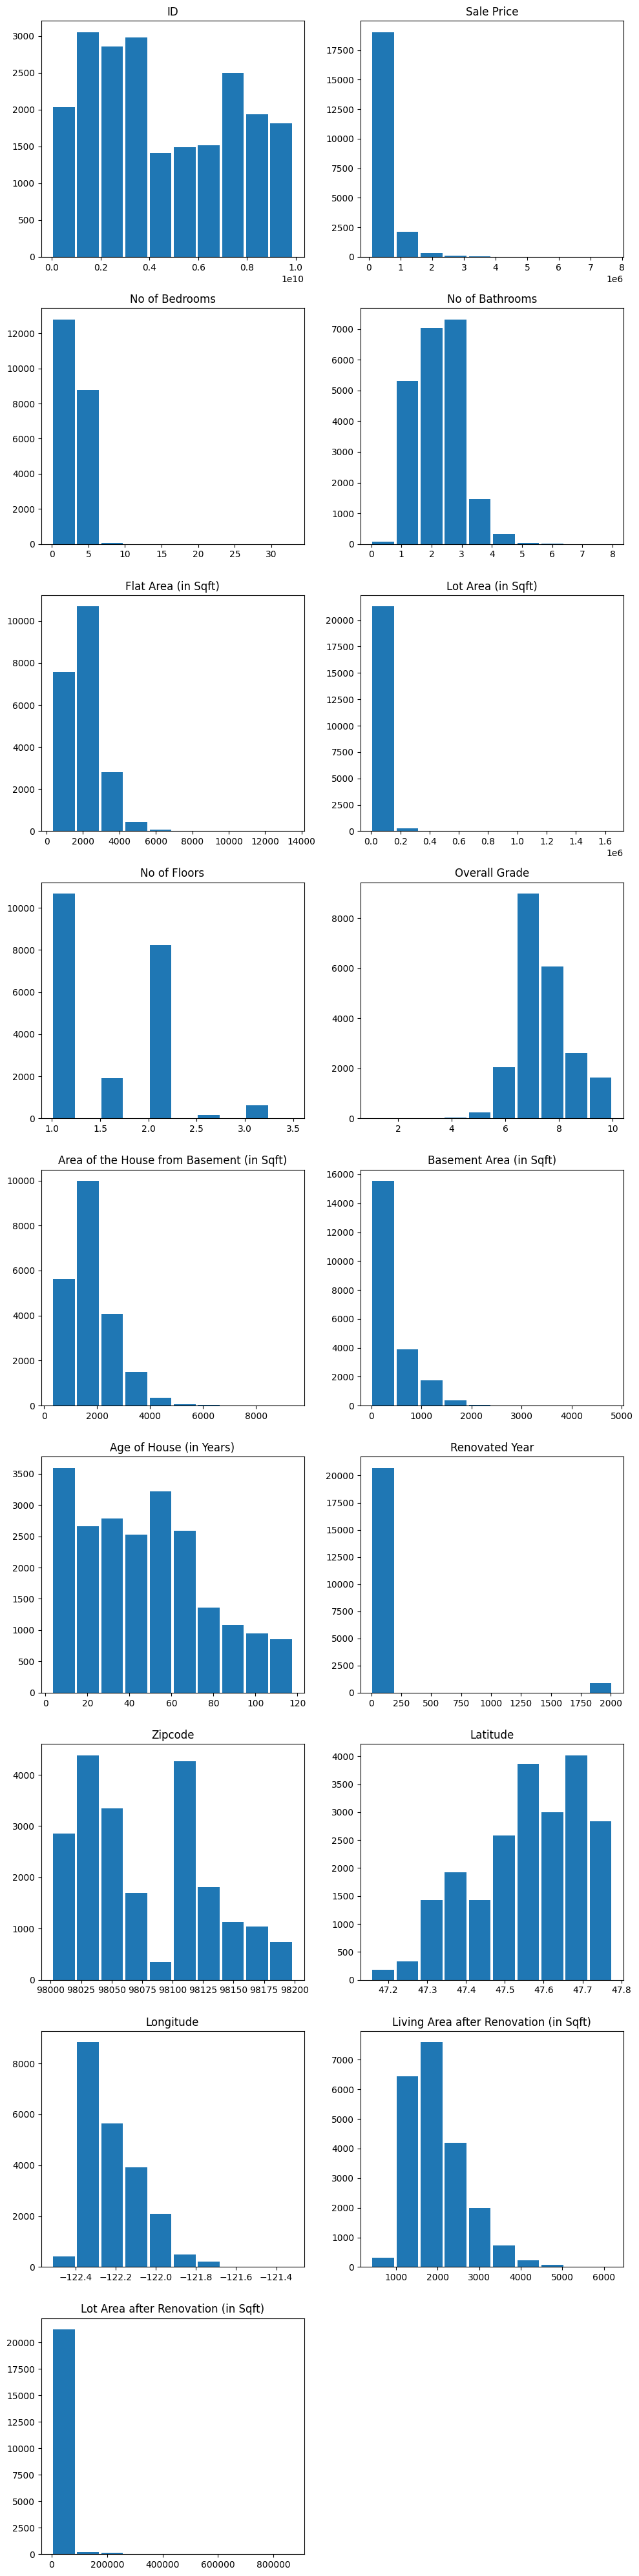

In [33]:
##Plot to understand numerical value distribution

plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.hist(House_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()


In [29]:
#Replacing all the values with median because distribution is skewed
House_df['Sale Price'].fillna(House_df['Sale Price'].median(), inplace=True)
House_df['No of Bathrooms'].fillna(House_df['No of Bathrooms'].median(), inplace=True)
House_df['Flat Area (in Sqft)'].fillna(House_df['Flat Area (in Sqft)'].median(), inplace=True)
House_df['Lot Area (in Sqft)'].fillna(House_df['Lot Area (in Sqft)'].median(), inplace=True)
House_df['Area of the House from Basement (in Sqft)'].fillna(House_df['Area of the House from Basement (in Sqft)'].median(), inplace=True)
House_df['Living Area after Renovation (in Sqft)'].fillna(House_df['Living Area after Renovation (in Sqft)'].median(), inplace=True)
House_df['Zipcode'].fillna(House_df['Zipcode'].median(),inplace=True)
House_df['Longitude'].fillna(House_df['Longitude'].median(),inplace=True)
House_df['Latitude'].fillna(House_df['Latitude'].median(),inplace=True)

/tmp/ipykernel_16388/3639818694.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  House_df['Sale Price'].fillna(House_df['Sale Price'].median(), inplace=True)
/tmp/ipykernel_16388/3639818694.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [30]:
House_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


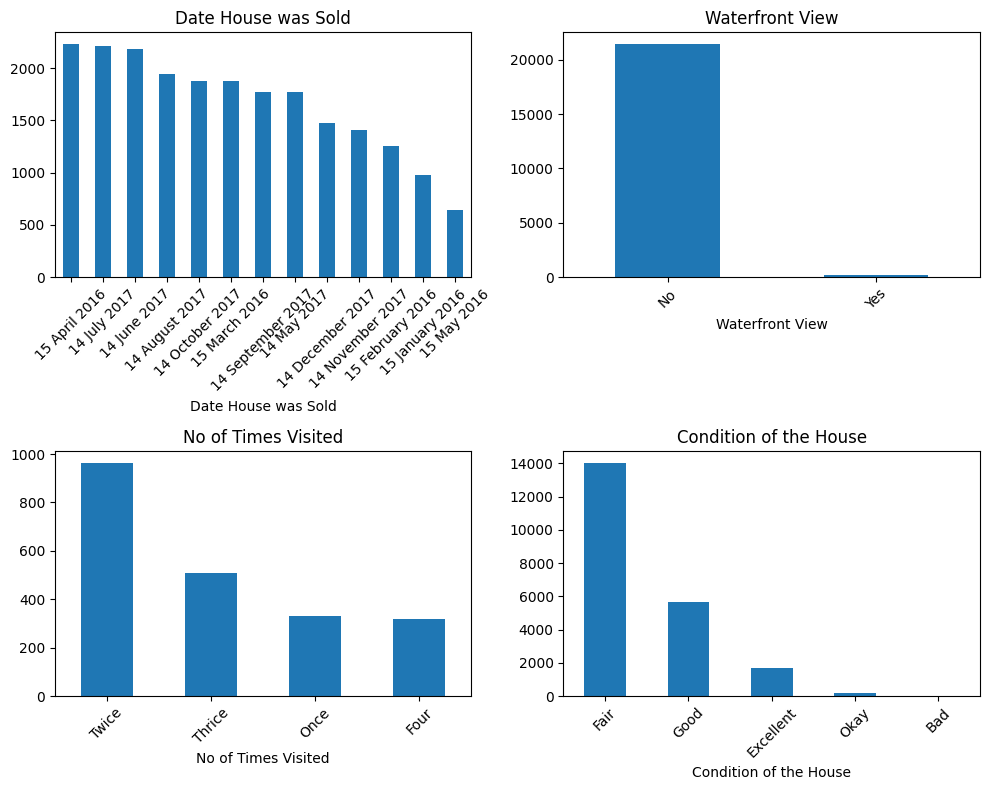

In [32]:
##Plot to understand categorical value dsistribution

plt.figure(figsize=(10,8))
for i, col in enumerate(cat_cols,1):
  plt.subplot(2,2,i)
  House_df[col].value_counts().plot(kind = 'bar')
  plt.title(col)
  plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [34]:
House_df.drop('No of Times Visited',axis=1, inplace=True) ##Dropping this column due to having null values more than 30%

In [36]:
House_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


##Outlier Handling

In [37]:
House_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401817e+05,3.370842,2.114757,2079.861010,1.510464e+04,1.494309,7.623467,1788.312497,291.509045,46.994864,84.402258,98077.937167,47.560048,-122.213892,1986.532133,12768.455652
std,2.876566e+09,3.673570e+05,0.930062,0.770069,918.302876,4.141992e+04,0.539989,1.105439,827.929506,442.575043,29.373411,401.679240,53.504259,0.138562,0.140827,685.389122,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


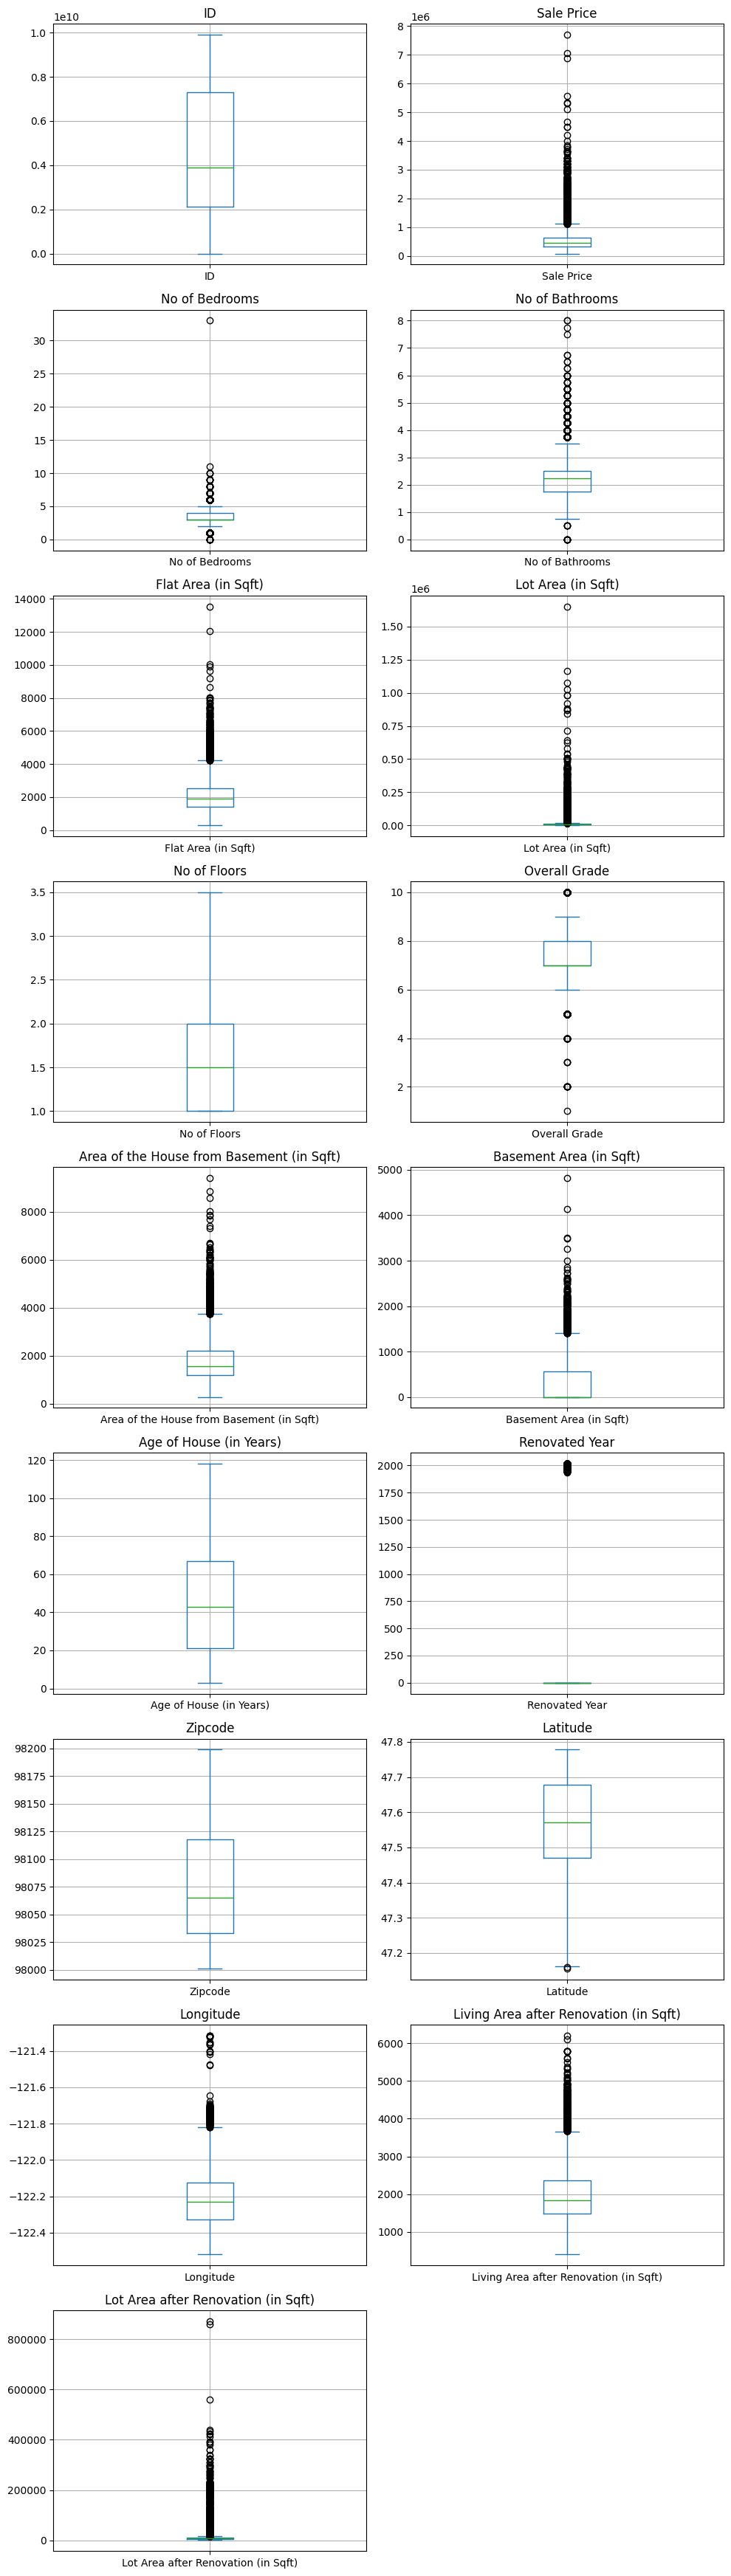

In [39]:
plt.figure(figsize=(10,35))
for i, col in enumerate (num_cols, 1):
  plt.subplot(9,2,i)
  House_df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()

In [41]:
Q1=House_df[num_cols].quantile(0.25)
Q3=House_df[num_cols].quantile(0.75)

IQR= Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((House_df[num_cols] > upper_limit) | (House_df[num_cols] < lower_limit)).any(axis=1)

outliers_df = House_df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(House_df)

print("percentage fo outliers in the dataframe :", outlier_percentage)



percentage fo outliers in the dataframe : 26.433165224633324


In [42]:
outliers_count = ((House_df[num_cols] > upper_limit) | (House_df[num_cols] < lower_limit)).mean()*100


In [43]:
outliers_count

,0
ID,0.000000
Sale Price,5.362513
No of Bedrooms,2.526257
No of Bathrooms,2.641928
Flat Area (in Sqft),2.646555
Lot Area (in Sqft),11.210845
No of Floors,0.000000
Overall Grade,8.841901
Area of the House from Basement (in Sqft),2.822375
Basement Area (in Sqft),2.294915


In [44]:

clip_cols= ['Lot Area (in Sqft)','Lot Area after Renovation (in Sqft)','Overall Grade', 'Renovated Year']

In [45]:
House_df[clip_cols] = House_df[clip_cols].clip(lower_limit, upper_limit, axis=1)

In [46]:

House_df = House_df[~outliers] # removing rest of the outliers

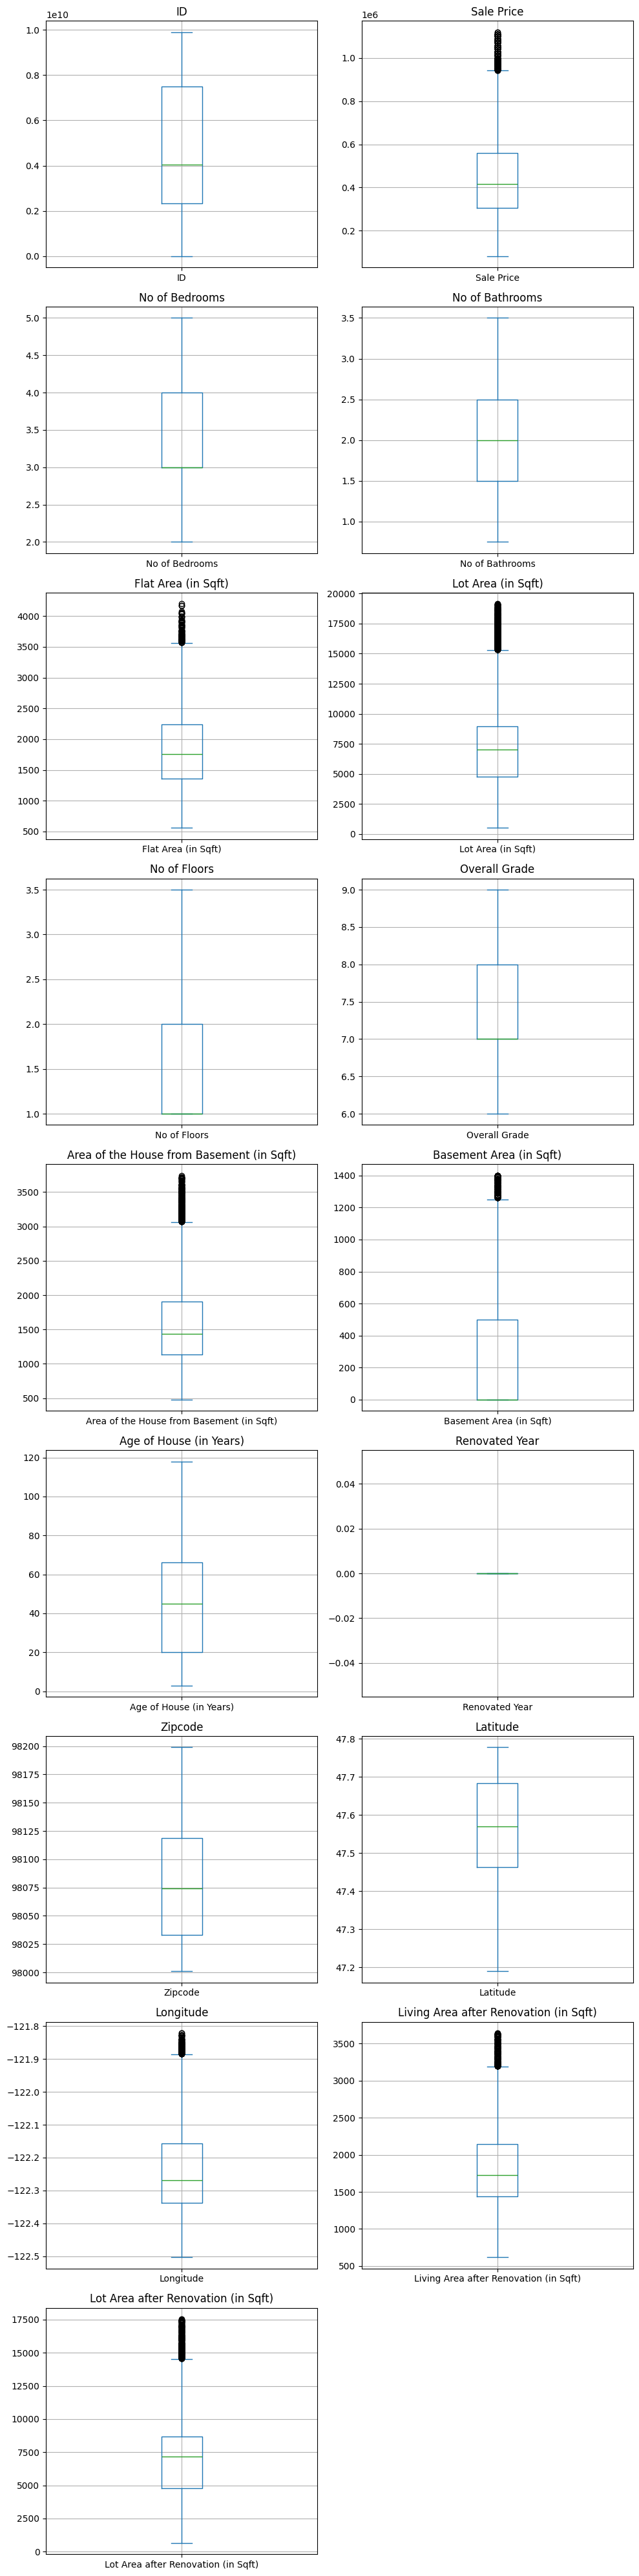

In [49]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  House_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [53]:

#House_df.drop('Renovated Year',axis=1,inplace=True)






In [52]:
num_cols = num_cols.drop('Renovated Year')


In [54]:
corr_matrix = House_df[num_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,0.037072,0.007453,0.045949,0.048309,-0.046412,0.033170,0.059330,0.056247,-0.009797,-0.041956,-0.033118,-0.007598,0.074676,0.056262,-0.049815
Sale Price,0.037072,1.000000,0.235779,0.340659,0.521054,-0.069494,0.213942,0.531470,0.399919,0.230763,0.029708,0.016894,0.478372,0.018304,0.464617,-0.075540
No of Bedrooms,0.007453,0.235779,1.000000,0.446127,0.609087,0.207501,0.125569,0.291149,0.479687,0.249782,-0.159461,-0.179120,-0.080549,0.185861,0.405502,0.198259
No of Bathrooms,0.045949,0.340659,0.446127,1.000000,0.670482,-0.072860,0.514540,0.581219,0.590673,0.171823,-0.592271,-0.235135,-0.052971,0.288456,0.503421,-0.075264
Flat Area (in Sqft),0.048309,0.521054,0.609087,0.670482,1.000000,0.177534,0.305943,0.626714,0.821848,0.352774,-0.339393,-0.212158,-0.025078,0.288763,0.719753,0.163812
Lot Area (in Sqft),-0.046412,-0.069494,0.207501,-0.072860,0.177534,1.000000,-0.408294,-0.015734,0.121057,0.103859,0.096948,-0.243135,-0.145757,0.213636,0.217355,0.878023
No of Floors,0.033170,0.213942,0.125569,0.514540,0.305943,-0.408294,1.000000,0.459403,0.518547,-0.331108,-0.544423,-0.066074,0.011742,0.144614,0.231494,-0.413800
Overall Grade,0.059330,0.531470,0.291149,0.581219,0.626714,-0.015734,0.459403,1.000000,0.634336,0.025700,-0.495015,-0.194685,0.059938,0.219749,0.602206,-0.005527
Area of the House from Basement (in Sqft),0.056247,0.399919,0.479687,0.590673,0.821848,0.121057,0.518547,0.634336,1.000000,-0.242562,-0.469569,-0.295472,-0.102811,0.415727,0.687475,0.107546
Basement Area (in Sqft),-0.009797,0.230763,0.249782,0.171823,0.352774,0.103859,-0.331108,0.025700,-0.242562,1.000000,0.193824,0.124118,0.126179,-0.191407,0.097217,0.102744


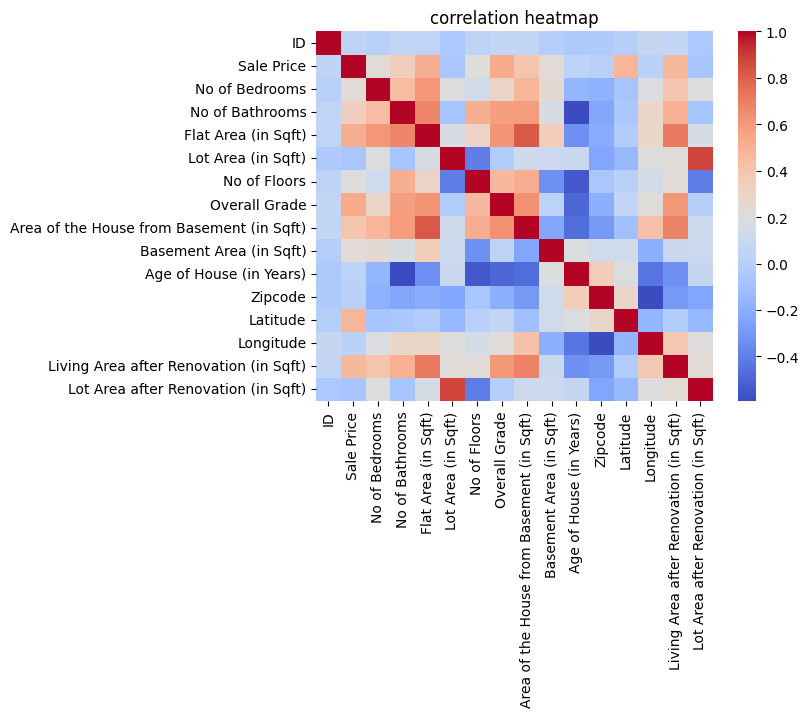

In [55]:
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [56]:
##Removing id from columns

House_df.drop(['ID'],axis=1, inplace=True)

/tmp/ipykernel_16388/2932816968.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  House_df.drop(['ID'],axis=1, inplace=True)


In [57]:
num_cols=num_cols.drop('ID')

In [58]:
House_df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7.0,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650.0
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6.0,770.0,0,85,98028.0,47.7379,-122.233,2720.0,8062.0
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7.0,1050.0,910,53,98136.0,47.5208,-122.393,1360.0,5000.0
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8.0,1680.0,0,31,98074.0,47.6168,-122.045,1800.0,7503.0
6,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,Fair,7.0,1715.0,0,23,98003.0,47.3097,-122.327,2238.0,6819.0


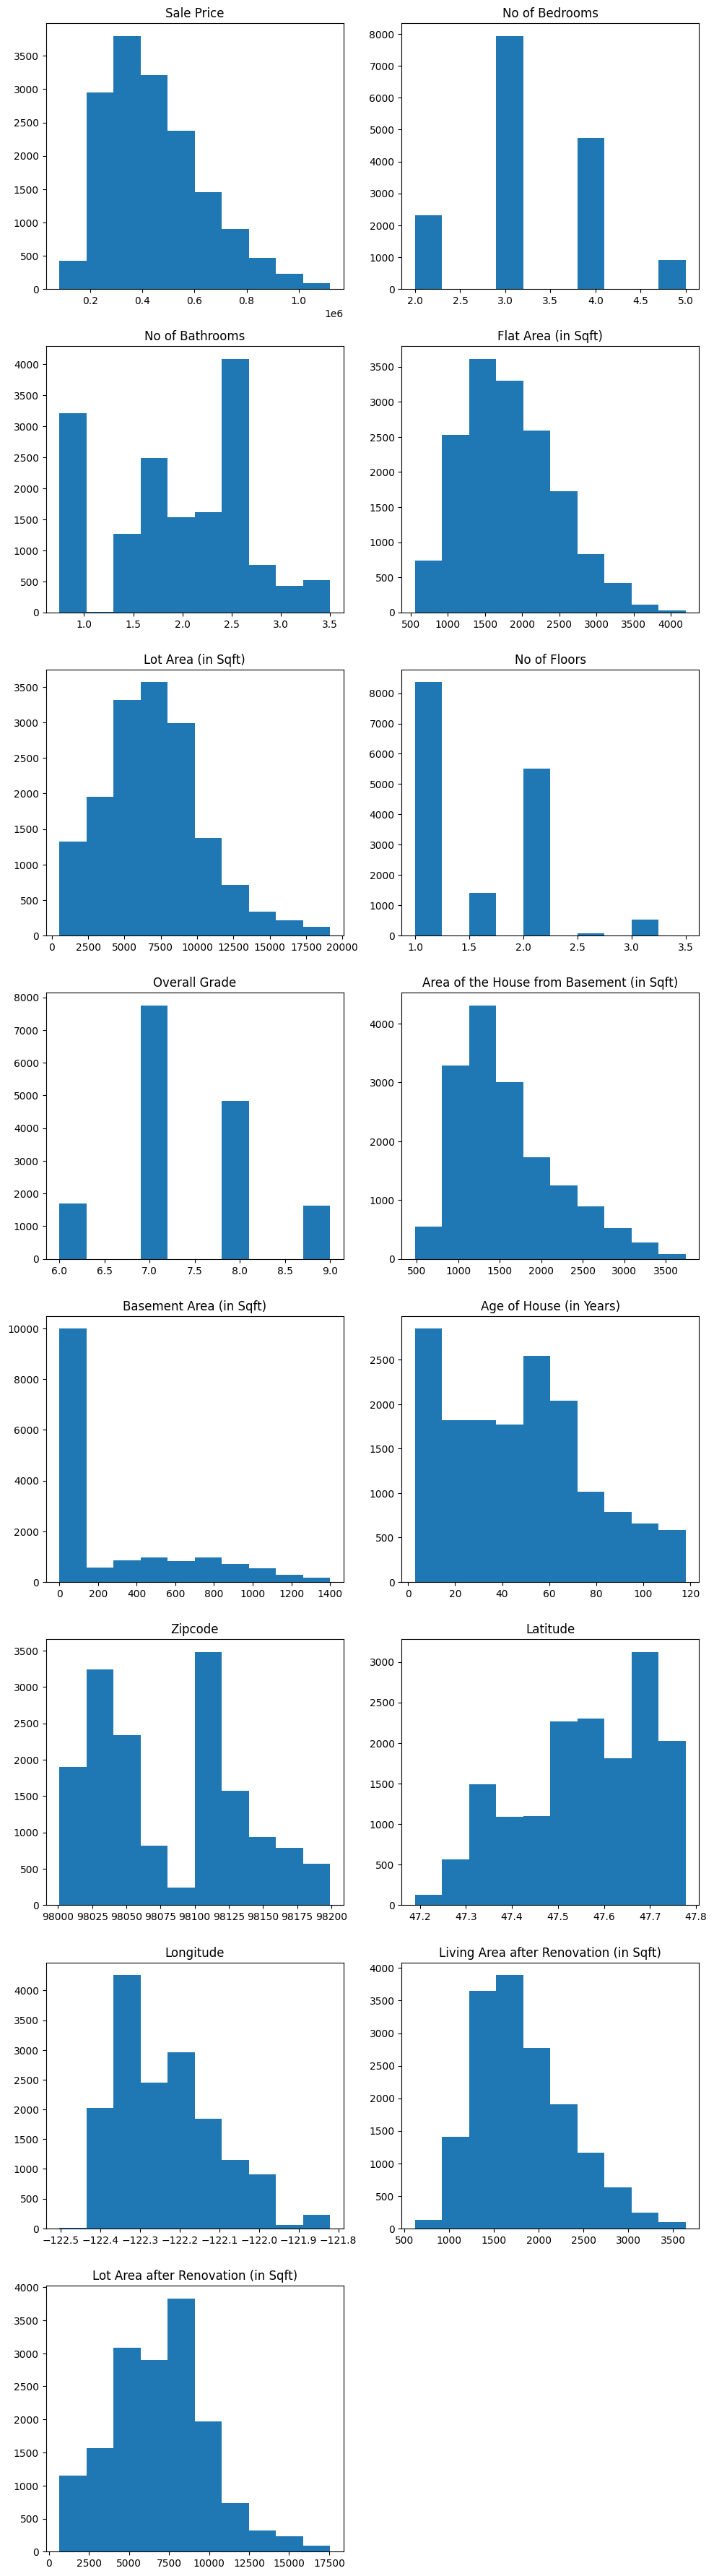

In [59]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.hist(House_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()


In [61]:
House_df.describe()  ##Before scaling

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.590000e+04,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.00000,15900.000000,15900.000000
mean,4.487819e+05,3.267736,1.981179,1834.896164,7030.641824,1.466069,7.402390,1588.989245,245.917421,46.947170,98081.505660,47.559489,-122.23347,1819.767862,6907.478365
std,1.862429e+05,0.775808,0.648012,621.912206,3375.398004,0.546501,0.811713,600.028235,364.970250,29.289552,54.131075,0.140797,0.12396,515.255245,3005.880095
min,8.200000e+04,2.000000,0.750000,560.000000,520.000000,1.000000,6.000000,480.000000,0.000000,3.000000,98001.000000,47.189500,-122.50300,620.000000,651.000000
25%,3.050000e+05,3.000000,1.500000,1360.000000,4749.500000,1.000000,7.000000,1140.000000,0.000000,20.000000,98033.000000,47.463100,-122.33700,1440.000000,4800.000000
50%,4.150000e+05,3.000000,2.000000,1760.000000,7027.500000,1.000000,7.000000,1440.000000,0.000000,45.000000,98074.000000,47.569600,-122.26900,1730.000000,7165.000000
75%,5.600000e+05,4.000000,2.500000,2240.000000,8977.750000,2.000000,8.000000,1910.000000,500.000000,66.000000,98119.000000,47.682500,-122.15600,2140.000000,8700.000000
max,1.120000e+06,5.000000,3.500000,4200.000000,19141.000000,3.500000,9.000000,3740.000000,1400.000000,118.000000,98199.000000,47.777600,-121.82100,3640.000000,17550.000000


In [62]:
# creating a list excluding target (sales price) for scaling

num_scale=['No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']


In [63]:
min_max_scaler= MinMaxScaler()
House_df[num_scale] = min_max_scaler.fit_transform(House_df[num_scale])

/tmp/ipykernel_16388/3410523489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  House_df[num_scale] = min_max_scaler.fit_transform(House_df[num_scale])


In [64]:
House_df.describe() ##After scaling

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.590000e+04,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000
mean,4.487819e+05,0.422579,0.447702,0.350246,0.349640,0.186428,0.467463,0.340181,0.175655,0.382149,0.406594,0.629125,0.395206,0.397274,0.370228
std,1.862429e+05,0.258603,0.235641,0.170855,0.181268,0.218600,0.270571,0.184058,0.260693,0.254692,0.273389,0.239411,0.181760,0.170614,0.177873
min,8.200000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.050000e+05,0.333333,0.272727,0.219780,0.227136,0.000000,0.333333,0.202454,0.000000,0.147826,0.161616,0.465227,0.243402,0.271523,0.245517
50%,4.150000e+05,0.333333,0.454545,0.329670,0.349471,0.000000,0.333333,0.294479,0.000000,0.365217,0.368687,0.646319,0.343109,0.367550,0.385467
75%,5.600000e+05,0.666667,0.636364,0.461538,0.454205,0.400000,0.666667,0.438650,0.357143,0.547826,0.595960,0.838293,0.508798,0.503311,0.476300
max,1.120000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [65]:
# corelation after scaling
corr_matrix = House_df[num_cols].corr(method='pearson')
corr_matrix


,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
Sale Price,1.000000,0.235779,0.340659,0.521054,-0.069494,0.213942,0.531470,0.399919,0.230763,0.029708,0.016894,0.478372,0.018304,0.464617,-0.075540
No of Bedrooms,0.235779,1.000000,0.446127,0.609087,0.207501,0.125569,0.291149,0.479687,0.249782,-0.159461,-0.179120,-0.080549,0.185861,0.405502,0.198259
No of Bathrooms,0.340659,0.446127,1.000000,0.670482,-0.072860,0.514540,0.581219,0.590673,0.171823,-0.592271,-0.235135,-0.052971,0.288456,0.503421,-0.075264
Flat Area (in Sqft),0.521054,0.609087,0.670482,1.000000,0.177534,0.305943,0.626714,0.821848,0.352774,-0.339393,-0.212158,-0.025078,0.288763,0.719753,0.163812
Lot Area (in Sqft),-0.069494,0.207501,-0.072860,0.177534,1.000000,-0.408294,-0.015734,0.121057,0.103859,0.096948,-0.243135,-0.145757,0.213636,0.217355,0.878023
No of Floors,0.213942,0.125569,0.514540,0.305943,-0.408294,1.000000,0.459403,0.518547,-0.331108,-0.544423,-0.066074,0.011742,0.144614,0.231494,-0.413800
Overall Grade,0.531470,0.291149,0.581219,0.626714,-0.015734,0.459403,1.000000,0.634336,0.025700,-0.495015,-0.194685,0.059938,0.219749,0.602206,-0.005527
Area of the House from Basement (in Sqft),0.399919,0.479687,0.590673,0.821848,0.121057,0.518547,0.634336,1.000000,-0.242562,-0.469569,-0.295472,-0.102811,0.415727,0.687475,0.107546
Basement Area (in Sqft),0.230763,0.249782,0.171823,0.352774,0.103859,-0.331108,0.025700,-0.242562,1.000000,0.193824,0.124118,0.126179,-0.191407,0.097217,0.102744
Age of House (in Years),0.029708,-0.159461,-0.592271,-0.339393,0.096948,-0.544423,-0.495015,-0.469569,0.193824,1.000000,0.347732,0.193260,-0.440279,-0.331701,0.075870


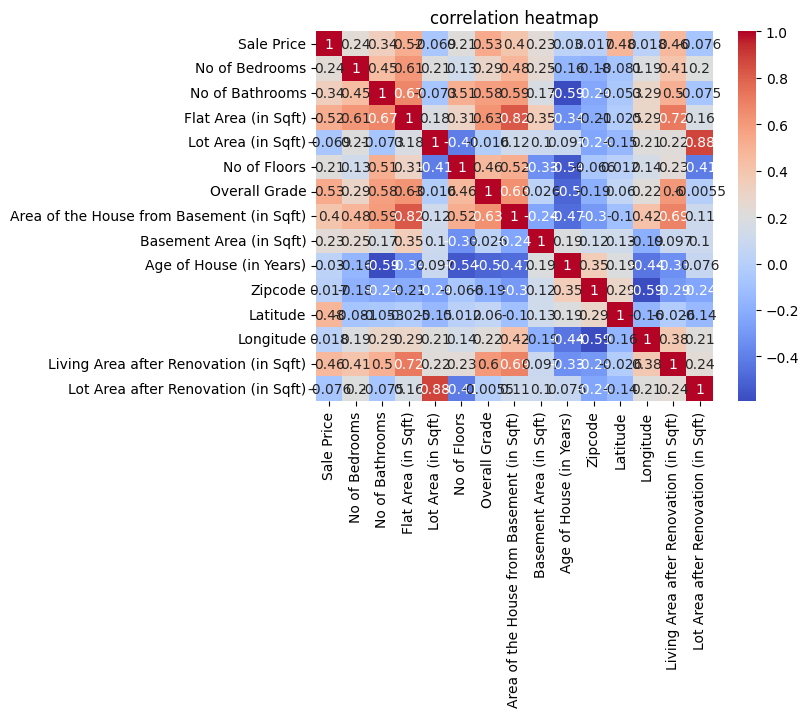

In [68]:

# ploting a heat map to visualize correlation after scaling
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

#Encoding

In [69]:
House_df.head(2) # before encoding


,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,No,Fair,0.333333,0.214724,0.0,0.521739,0.893939,0.547016,0.360704,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,No,Fair,0.000000,0.088957,0.0,0.713043,0.136364,0.932494,0.395894,0.695364,0.438547


In [70]:
House_df['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [71]:
House_df['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Okay', 'Bad'], dtype=object)

In [72]:
label_encoder = LabelEncoder()

House_df['Waterfront View'] = label_encoder.fit_transform(House_df['Waterfront View'])
House_df['Condition of the House'] = label_encoder.fit_transform(House_df['Condition of the House'])


/tmp/ipykernel_16388/941293533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  House_df['Waterfront View'] = label_encoder.fit_transform(House_df['Waterfront View'])
/tmp/ipykernel_16388/941293533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  House_df['Condition of the House'] = label_encoder.fit_transform(House_df['Condition of the House'])


In [73]:
House_df.head(5)  ##After encoding

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,0,2,0.333333,0.214724,0.00,0.521739,0.893939,0.547016,0.360704,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,0,2,0.000000,0.088957,0.00,0.713043,0.136364,0.932494,0.395894,0.695364,0.438547
3,14 December 2017,604000.0,0.666667,0.818182,0.384615,0.240589,0.0,0,1,0.333333,0.174847,0.65,0.434783,0.681818,0.563340,0.161290,0.245033,0.257353
4,15 February 2016,510000.0,0.333333,0.454545,0.307692,0.405993,0.0,0,2,0.666667,0.368098,0.00,0.243478,0.368687,0.726577,0.671554,0.390728,0.405468
6,14 June 2017,257500.0,0.333333,0.545455,0.317308,0.338274,0.4,0,2,0.333333,0.378834,0.00,0.173913,0.010101,0.204387,0.258065,0.535762,0.364992


##Train-Test Split

In [76]:
y = House_df['Sale Price']   # Target

X = House_df.drop(columns=['Sale Price'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (12720, 17)
X_test shape: (3180, 17)
y_train shape: (12720,)
y_test shape: (3180,)
